# Us Airport

## Loading dataset

In [1]:
import networkx as nx

G = nx.Graph()

with open('./data/raw/usairport.txt') as f:
    for line in f:
        u,v,w = map(int, line.split())
        G.add_edge(u,v)

In [2]:
degrees = [d for _, d in G.degree()]

## Network analysis 

### Degree distribution

In [3]:
from collections import Counter

degree_count = Counter(degrees)
N = len(degrees)

k = list(degree_count.keys())
pk = [count / N for count in degree_count.values()]

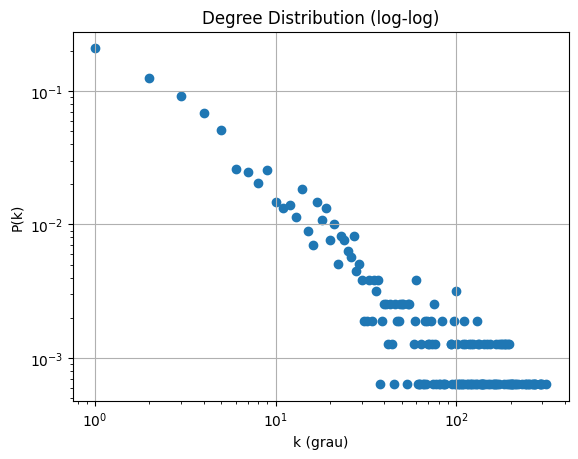

In [4]:
import matplotlib.pyplot as plt

plt.scatter(k, pk)
plt.xscale('log')
plt.yscale('log')

plt.xlabel("k (grau)")
plt.ylabel("P(k)")
plt.title("Degree Distribution (log-log)")

plt.grid(True)
plt.show()

## Average Clustering coefficient

### Global Clustering coefficient/Transitivity

$$
T = \frac{3 \times \text{number of triangles}}{\text{number of connected triples}}
$$

#### Complexity Analysis

A função `transitivity_manual` é composta por 3 momentos:
1. Utilizamos a função `nx.triangles` para encontrar os triângulos na rede. Essa função no pior caso é $O(N^3)$ e no melhor caso é $O(N)$. A função pode ser encontrada em [nx.triangles](https://networkx.org/documentation/stable/_modules/networkx/algorithms/cluster.html#triangles)
2. Depois temos um for que com base no grau dele calcula o número de triangulos formados com complexidade $O(N)$
3. E por ultimo temos alguma execuções com complexidade $O(N)$

Com isso podemos concluir que a complexidade é dada pela função `nx.triangles`
$$
O(Nˆ3)
$$


In [5]:

def transitivity_manual(G):
    triangles_per_node = nx.triangles(G)
    total_triangles = sum(triangles_per_node.values()) / 3

    triples = 0
    for node in G.nodes():
        k = G.degree(node)
        triples += k * (k - 1) / 2 

    if triples == 0:
        return 0

    T = (3 * total_triangles) / triples
    return T


In [6]:
print(f'transitivity NX Lib: {nx.transitivity(G):.2f}')
print(f'transitivity Manual: {transitivity_manual(G):.2f}')

transitivity NX Lib: 0.38
transitivity Manual: 0.38


### Local Cluestering coefficient

$$
C_L = \sum\limits_{i=1}^{N}\frac{C_i}{N}
$$
Onde $C_i$ é:

$$
C_i = \frac{e_i}{k_i\times(k_i-1)/2}
$$

Onde $e_i$ representa num de conexões entre os vizinhos de $i$. Já $k_i$ representa o grau (número de conexões de $i$).

#### Complexity Analysis

A função `neighbors_inter_connections` mede quantos pares de vizinhos eu consigo formar. 
Exemplo: Para um nó i de grau K=4 com *neighbors* (A, B, C, D), posso formar
(A, B)
(A, C)
(A, D)
(B, C)
(B, D)
(C, D)

E isso pode ser representado por $\binom{K}{2}$ onde $K$ representa o grau do nó. 
Portanto, temos que a complixadade de `neighbors_inter_connections` pode ser representada por:
$$
O\binom{K}{2} = \frac{K(K-1)}{2} \to O(K^2)
$$

Já a função `local_clustering` executa a função `neighbors_inter_connections` N vezes, onde N é o número de nós da rede. Portanto temos que:

$$
\sum\limits_{i=1}^{N}{O(K^2)} = {O(\sum\limits_{i=1}^{N}{K^2})}
$$

Agora temos que $\langle k^2 \rangle = \frac{1}{N}*\sum\limits_{i=1}^{N}{K^2}$, portanto temos que a complexidade por ser escrita por 

$$
O(N * \langle k^2 \rangle)
$$

Com isso pode concluir que a complexidade desse algoritmo depende diretamente do grau da rede. Então para uma rede com muitos *hubs* (uma rede densa), temos valor de K médio é alto e com isso temos $O(N^3)$. Já para uma rede esparsa temo um valor de K pequeno e com isso temos $O(N)$.

In [7]:
def neighbors_inter_connections(G, node):
    neighbors = list(G.neighbors(node))
    count = 0

    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if G.has_edge(neighbors[i], neighbors[j]):
                count += 1

    return count
    

In [8]:
def local_clustering(G, N):
    e = neighbors_inter_connections(G, N)
    k = G.degree(N)

    if e == 0 or k == 0:
        return 0
    return e/(k*(k-1)/2)

In [9]:
C_i = 0
N = G.number_of_nodes()
for node in G:
    C_i = C_i + local_clustering(G, node)


print(f'Average Clustering NX Lib: {nx.average_clustering(G):.2f}')
print(f'Average Clustering Manual: {C_i/N:.2f}')


Average Clustering NX Lib: 0.50
Average Clustering Manual: 0.50


## Complexity Coefficient

Considerando o coeficiente de complexidade como:
$$
C = \frac{\langle k_2 \rangle}{\langle k_1 \rangle}
$$

Onde $\langle k_i \rangle$ é representado por:
$$
\langle k_i \rangle = \frac{1}{N}\sum_{i=1}^{n} k_i^n
$$



In [10]:
import numpy as np

def degree_moment(degrees, n):
    degrees = np.array(degrees)
    return np.mean(degrees ** n)

In [11]:
degrees = [d for _, d in G.degree()]

k_1 = degree_moment(degrees,1)
k_2 = degree_moment(degrees,2)

print(f'{(k_2/k_1):.2f}')

112.22


## Shannon Entropy

A Entropia de Shannon pode ser descrita pela formula

$$
H(X) = - \sum\limits_{i=1}^n{p(x_i)*log_2(p(x_i))}
$$

Um valor de 0 indica certeza total (um evento sempre ocorre), enquanto valores mais altos indicam maior imprevisibilidade ou aleatoriedade.

Trazendo para o mundo de redes complexas o $p$ representa a probabilidade de um nó $N$ ter um grau $k$. com isso a fórmula fica
$$
H(X) = - \sum\limits_{i=1}^n{p(k_i)*log_2(p(k_i))}
$$


In [12]:
import math

h = 0 
for p in pk:
    h = h + (p*math.log2(p))

h = -h

print(f'Shannon Entropy: {h:.2f}')

Shannon Entropy: 4.99
